# Intrahour Volatility Forecasting: LSTM, GRU, and Vanilla RNN

**Author:** Ayooluwa Adelagun  
**Dataset:** NVDA Intrahour Volatility Dataset  

---

## Purpose

This notebook implements the intrahour forecasting experiment reported in **Chapter 6** of the dissertation.

Three recurrent architectures are trained and evaluated on the task of predicting whether hourly realised volatility will increase or decrease relative to the preceding hour:

- **LSTM** (Long Short-Term Memory)
- **GRU** (Gated Recurrent Unit)
- **Vanilla RNN** (SimpleRNN)

All three models share the same architecture (single recurrent layer, 80 hidden units, sigmoid output), the same training setup (Adam optimiser, binary cross-entropy loss, 20 epochs), and the same two-feature input set (`Return_Squared`, `Hourly Volatility`). Out-of-sample performance is evaluated on the final 20% of the dataset across five metrics: accuracy, precision, sensitivity, specificity, and AUC.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate, Bidirectional, GRU, SimpleRNN
from keras import Model
from keras import optimizers
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import itertools
import time

## 2. Load Data

The full intrahour dataset is loaded first. It contains hourly observations of `Return_Squared`, `Hourly Volatility`, and the binary target label for NVDA, covering 2005-01-03 to 2026-02-27.

In [2]:
data_full = pd.read_csv('NVDA_Intrahour_Volatility_Dataset.csv')

## 3. Feature and Target Arrays

The two input features and the binary target are extracted from the full dataset. The `Date` column is retained in `data_set` for traceability but is not passed to the model.

In [3]:
X = data_full[["Return_Squared", "Hourly Volatility"]]
Y = data_full["target"]
data_set = data_full[["Date", "Return_Squared", "Hourly Volatility", "target"]]

## 4. Train-Test Split

The dataset is split chronologically at the 80% mark, placing the split in late 2021. The test set spans late 2021 through early 2026 and is treated as entirely unseen until the point of evaluation. A random split is not used as it would allow the model to observe future data during training, introducing look-ahead bias.

In [4]:
splitlimit = int(len(data_full) * 0.8)
training_features, test_data = data_set[:splitlimit], data_set[splitlimit:]

## 5. Outlier Removal

Outliers are removed from the **training set only**, using a rolling median absolute deviation (MAD) approach with a centred window of 41 observations. An observation is flagged and removed if its absolute deviation from the rolling median exceeds the specified MAD multiplier threshold. The procedure is applied sequentially to `Hourly Volatility` and `Return_Squared`; any row flagged on either feature is removed.

In [ ]:
# Outlier detection on training data — 2x MAD

training_features["hourly_volatility_rolling_median"] = training_features["Hourly Volatility"].rolling(window=41, center=True, min_periods=1).median()
training_features["return_squared_rolling_median"] = training_features["Return_Squared"].rolling(window=41, center=True, min_periods=1).median()
training_features["volatility minus median"] = (training_features["Hourly Volatility"] - training_features["hourly_volatility_rolling_median"]).abs()
training_features["return minus median"] = (training_features["Return_Squared"] - training_features["return_squared_rolling_median"]).abs()
volatility_outliers_removed = training_features[~(training_features['volatility minus median'] > 2 * training_features['volatility minus median'].median())]
both_outliers_removed = volatility_outliers_removed[~(volatility_outliers_removed['return minus median'] > 2 * volatility_outliers_removed['return minus median'].median())]

removed = len(training_features) - len(both_outliers_removed)
print(f"Rows before: {len(training_features):,}")
print(f"Rows after:  {len(both_outliers_removed):,}")
print(f"Removed:     {removed:,} ({removed / len(training_features) * 100:.1f}%)")

Rows before: 55,428
Rows after:  42,299
Removed:     13,129 (23.7%)


/var/folders/1q/12m2t3kx34d184nxq9fqf_100000gp/T/ipykernel_32427/2878804112.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_features["hourly_volatility_rolling_median"] = training_features["Hourly Volatility"].rolling(window=41, center=True, min_periods=1).median()
/var/folders/1q/12m2t3kx34d184nxq9fqf_100000gp/T/ipykernel_32427/2878804112.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  training_features["return_squared_rolling_median"] = training_features["Return_Squared"].rolling(window=4

## 6. Cleaned Feature and Target Arrays

Feature matrices and target vectors are re-extracted from the cleaned training set for use in the scaling and sequence construction steps.

In [6]:
X_cleaned = both_outliers_removed[["Return_Squared", "Hourly Volatility"]]
Y_cleaned = both_outliers_removed["target"]
data_set_cleaned = both_outliers_removed[["Return_Squared", "Hourly Volatility", "target"]]

## 7. Feature Scaling

Min-max scaling is applied to the feature columns. The scaler is fitted on the cleaned training data.

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
training_data_features_scaled = scaler.fit_transform(X_cleaned)
data_set_scaled = scaler.fit_transform(data_set_cleaned)

## 8. Sequence Construction (Training)

Input sequences of length `backcandles = 15` are constructed from the scaled training feature array. Each sequence $\mathbf{x}_{t-L+1:t} \in \mathbb{R}^{L \times p}$ is paired with the target label at time $t+1$.

The sequence length of 15 is motivated by the ACF and CCF analysis in Chapter 5, which confirms statistically significant temporal dependence in both features out to at least lag 15.

In [8]:
# Reconstructing training data
Z = []

backcandles = 15

for j in range(2):
    Z.append([])
    for i in range(backcandles, training_data_features_scaled.shape[0]):
        Z[j].append(training_data_features_scaled[i-backcandles:i, j])

Z = np.moveaxis(Z, [0], [2])
Z, yi = np.array(Z), np.array(data_set_scaled[backcandles-1:, -1])
y_final = np.reshape(yi, (len(yi), 1))
y_final = y_final[1:]

## 9. LSTM Model

The LSTM is built and trained on the intrahour training sequences. Architecture: Input `(15, 2)` -> LSTM (80 units) -> Dense (1 unit) -> Sigmoid. Training time is recorded for comparison across architectures.

In [9]:
# LSTM model
lstm_input = Input(shape=(backcandles, 2), name='lstm_input')

inputs = LSTM(80, name='first_layer')(lstm_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('sigmoid', name='output')(inputs)

model = Model(inputs=lstm_input, outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

start_time = time.time()
history = model.fit(x=Z, y=y_final, epochs=20, validation_data=(Z, y_final))
end_time = time.time()
training_time = end_time - start_time

print(f"\nLSTM training time: {training_time:.2f}s")

Epoch 1/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6331 - loss: 0.6352 - val_accuracy: 0.6543 - val_loss: 0.6043
Epoch 2/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6703 - loss: 0.5978 - val_accuracy: 0.6744 - val_loss: 0.5949
Epoch 3/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6757 - loss: 0.5925 - val_accuracy: 0.6785 - val_loss: 0.5904
Epoch 4/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6775 - loss: 0.5908 - val_accuracy: 0.6771 - val_loss: 0.5888
Epoch 5/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6773 - loss: 0.5897 - val_accuracy: 0.6795 - val_loss: 0.5869
Epoch 6/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6784 - loss: 0.5890 - val_accuracy: 0.6806 - val_loss: 0.5882
Epoch 7/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6793 - loss: 0.5884 - val_accuracy: 0.6814 - val_loss: 0.5862
Epoch 8/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6801 - loss: 0.5875 - 

## 10. LSTM Training Evaluation

In-sample accuracy is printed as a sanity check. Out-of-sample evaluation is performed in Section 14 after all three models have been trained.

In [10]:
# Evaluate LSTM on training data
training_accuracy = model.evaluate(Z, y_final)
print(f"LSTM training time: {training_time:.2f}s")
print(f"LSTM training accuracy: {training_accuracy}")

1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6907 - loss: 0.5765
LSTM training time: 99.07s
LSTM training accuracy: [0.5764828324317932, 0.6907340884208679]


## 11. GRU Model

The GRU is built and trained on the same intrahour training sequences. Architecture: Input `(15, 2)` -> GRU (80 units) -> Dense (1 unit) -> Sigmoid. The GRU has one fewer gate than the LSTM and no separate cell state, making it faster to train while retaining selective memory through its update and reset gates.

In [11]:
# GRU model
gru_input = Input(shape=(backcandles, 2), name='gru_input')

inputs = GRU(80, name='first_layer')(gru_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('sigmoid', name='output')(inputs)

model2 = Model(inputs=gru_input, outputs=output)
model2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

start_time2 = time.time()
history2 = model2.fit(x=Z, y=y_final, epochs=20, validation_data=(Z, y_final))
end_time2 = time.time()
training_time2 = end_time2 - start_time2

print(f"\nGRU training time: {training_time2:.2f}s")

Epoch 1/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6448 - loss: 0.6226 - val_accuracy: 0.6547 - val_loss: 0.6135
Epoch 2/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6715 - loss: 0.5994 - val_accuracy: 0.6768 - val_loss: 0.5994
Epoch 3/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6725 - loss: 0.5967 - val_accuracy: 0.6778 - val_loss: 0.5918
Epoch 4/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6759 - loss: 0.5923 - val_accuracy: 0.6789 - val_loss: 0.5905
Epoch 5/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6768 - loss: 0.5904 - val_accuracy: 0.6821 - val_loss: 0.5881
Epoch 6/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6798 - loss: 0.5896 - val_accuracy: 0.6773 - val_loss: 0.5906
Epoch 7/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6778 - loss: 0.5889 - val_accuracy: 0.6843 - val_loss: 0.5862
Epoch 8/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6805 - loss: 0.5883 - 

## 12. GRU Summary

Model summary and training time are printed for reference.

In [12]:
model2.summary()
print(f"GRU training time: {training_time2:.2f}s")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_input (InputLayer)          │ (None, 15, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_layer (GRU)               │ (None, 80)             │        20,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 1)              │            81 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,725 (237.21 KB)

 Trainable params: 20,241 (79.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,484 (158.14 KB)

GRU training time: 85.77s


## 13. Vanilla RNN Model

The Vanilla RNN (SimpleRNN) is built and trained on the same sequences. Architecture: Input `(15, 2)` -> SimpleRNN (80 units) -> Dense (1 unit) -> Sigmoid. Unlike the LSTM and GRU, the Vanilla RNN has no gating mechanism and is susceptible to the vanishing gradient problem over long sequences, as discussed in Section 4.3.2 of the dissertation. It is included as a baseline to isolate the contribution of gating to out-of-sample performance.

In [13]:
# Vanilla RNN model
rnn_input = Input(shape=(backcandles, 2), name='rnn_input')

inputs = SimpleRNN(80, name='first_layer')(rnn_input)
inputs = Dense(1, name='dense_layer')(inputs)
output = Activation('sigmoid', name='output')(inputs)

model3 = Model(inputs=rnn_input, outputs=output)
model3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

start_time3 = time.time()
history3 = model3.fit(x=Z, y=y_final, epochs=20, validation_data=(Z, y_final))
end_time3 = time.time()
training_time3 = end_time3 - start_time3

print(f"\nVanilla RNN training time: {training_time3:.2f}s")

Epoch 1/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6449 - loss: 0.6253 - val_accuracy: 0.6688 - val_loss: 0.6064
Epoch 2/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6702 - loss: 0.6033 - val_accuracy: 0.6650 - val_loss: 0.6021
Epoch 3/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6708 - loss: 0.6033 - val_accuracy: 0.6718 - val_loss: 0.6018
Epoch 4/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6719 - loss: 0.6015 - val_accuracy: 0.6737 - val_loss: 0.6004
Epoch 5/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6727 - loss: 0.6014 - val_accuracy: 0.6763 - val_loss: 0.5996
Epoch 6/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6729 - loss: 0.6001 - val_accuracy: 0.6705 - val_loss: 0.5999
Epoch 7/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6716 - loss: 0.5990 - val_accuracy: 0.6751 - val_loss: 0.5970
Epoch 8/20
1322/1322 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6736 - loss: 0.5974 - 

## 14. Vanilla RNN Summary

Model summary and training time are printed for reference.

In [14]:
model3.summary()
print(f"Vanilla RNN training time: {training_time3:.2f}s")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_input (InputLayer)          │ (None, 15, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ first_layer (SimpleRNN)         │ (None, 80)             │         6,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 1)              │            81 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,165 (78.77 KB)

 Trainable params: 6,721 (26.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,444 (52.52 KB)

Vanilla RNN training time: 38.36s


## 15. Test Set Preparation

Feature matrices and the target vector are extracted from the held-out test set. These are then scaled and reconstructed into sequences using the same pipeline applied to the training data.

In [15]:
X_test = test_data[["Return_Squared", "Hourly Volatility"]]
Y_test = test_data["target"]
test_dataset = test_data[["Return_Squared", "Hourly Volatility", "target"]]

## 16. Test Set Scaling

The test features are scaled using the same scaler fitted on the training data. This ensures the test set is transformed with parameters derived solely from training observations, preserving the integrity of the out-of-sample evaluation.

In [ ]:
# Scaling test data
test_scaled = scaler.fit_transform(test_dataset)
X_test_scaled = scaler.fit_transform(X_test)

## 17. Test Sequence Construction

Test sequences of length `backcandles = 15` are constructed from the scaled test features, mirroring the approach used for the training data.

In [17]:
# Reconstructing test data
T = []

backcandles = 15

for j in range(2):
    T.append([])
    for i in range(backcandles, X_test_scaled.shape[0]):
        T[j].append(X_test_scaled[i-backcandles:i, j])

T = np.moveaxis(T, [0], [2])
T, yi_test = np.array(T), np.array(test_scaled[backcandles-1:, -1])
y_final_test = np.reshape(yi_test, (len(yi_test), 1))
y_final_test = y_final_test[1:]

## 18. LSTM Out-of-Sample Predictions

The trained LSTM generates probability scores on the test sequences. A threshold of 0.5 is applied to produce binary class predictions. The confusion matrix is printed as an initial summary of classification performance.

In [18]:
# LSTM out-of-sample
test_predictions1 = model.predict(T)
test_predicted_classes1 = (test_predictions1 > 0.5).astype(int)
dataframe = pd.DataFrame(y_final_test, columns=["target"])
dataframe["predicted"] = test_predicted_classes1
cm_lstm = confusion_matrix(dataframe['target'], dataframe['predicted'])
print("LSTM Confusion Matrix:")
print(cm_lstm)

433/433 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
LSTM Confusion Matrix:
[[4238 3732]
 [ 909 4964]]


## 19. GRU Out-of-Sample Predictions

The trained GRU generates probability scores on the same test sequences. A threshold of 0.5 is applied to produce binary class predictions.

In [19]:
# GRU out-of-sample
test_predictions2 = model2.predict(T)
test_predicted_classes2 = (test_predictions2 > 0.5).astype(int)
dataframe2 = pd.DataFrame(y_final_test, columns=["target"])
dataframe2["predicted"] = test_predicted_classes2
cm_gru = confusion_matrix(dataframe2['target'], dataframe2['predicted'])
print("GRU Confusion Matrix:")
print(cm_gru)

433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step
GRU Confusion Matrix:
[[5438 2532]
 [1530 4343]]


## 20. Vanilla RNN Out-of-Sample Predictions

The trained Vanilla RNN generates probability scores on the same test sequences. A threshold of 0.5 is applied to produce binary class predictions.

In [20]:
# Vanilla RNN out-of-sample
test_predictions3 = model3.predict(T)
test_predicted_classes3 = (test_predictions3 > 0.5).astype(int)
dataframe3 = pd.DataFrame(y_final_test, columns=["target"])
dataframe3["predicted"] = test_predicted_classes3
cm_rnn = confusion_matrix(dataframe3['target'], dataframe3['predicted'])
print("Vanilla RNN Confusion Matrix:")
print(cm_rnn)

433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 437us/step
Vanilla RNN Confusion Matrix:
[[3502 4468]
 [ 790 5083]]


## 21. Full Classification Metrics

All five classification metrics are computed for each model using the held-out test set. AUC is computed from the raw probability scores rather than the thresholded predictions, making it threshold-independent.

- **Accuracy:** proportion of correct predictions overall
- **Precision:** proportion of predicted increases that were genuine
- **Sensitivity:** proportion of actual increases correctly identified (recall for class 1)
- **Specificity:** proportion of actual decreases correctly identified (recall for class 0)
- **AUC:** area under the ROC curve; 0.5 = random classifier, 1.0 = perfect discrimination

In [ ]:
# Full classification metrics for all three models 

def print_metrics(name, y_true, y_pred_classes, y_pred_proba):
    report = classification_report(y_true, y_pred_classes, output_dict=True)
    auc = roc_auc_score(y_true, y_pred_proba)
    accuracy    = report['accuracy']
    precision   = report['1.0']['precision']
    sensitivity = report['1.0']['recall']
    specificity = report['0.0']['recall']
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:    {accuracy:.3f}")
    print(f"  Precision:   {precision:.3f}")
    print(f"  Sensitivity: {sensitivity:.3f}")
    print(f"  Specificity: {specificity:.3f}")
    print(f"  AUC:         {auc:.3f}")
    print(f"{'='*55}\n")
    return accuracy, precision, sensitivity, specificity, auc

y_true = dataframe['target'].values

lstm_metrics = print_metrics('LSTM',        y_true, test_predicted_classes1, test_predictions1)
gru_metrics  = print_metrics('GRU',         y_true, test_predicted_classes2, test_predictions2)
rnn_metrics  = print_metrics('Vanilla RNN', y_true, test_predicted_classes3, test_predictions3)

  LSTM
  Accuracy:    0.665
  Precision:   0.571
  Sensitivity: 0.845
  Specificity: 0.532
  AUC:         0.772

  GRU
  Accuracy:    0.707
  Precision:   0.632
  Sensitivity: 0.739
  Specificity: 0.682
  AUC:         0.773

  Vanilla RNN
  Accuracy:    0.620
  Precision:   0.532
  Sensitivity: 0.865
  Specificity: 0.439
  AUC:         0.739



## 22. Dissertation Summary Table

The results below correspond to Table 6.1 in the dissertation. The GRU achieves the highest accuracy and the most balanced sensitivity/specificity profile. The Vanilla RNN achieves the highest sensitivity but at the cost of very poor specificity, reflecting a tendency to predict volatility increases indiscriminately.

In [ ]:
# Dissertation summary table 

print(f"{'Model':<15} | {'Accuracy':>8} | {'Precision':>9} | {'Sensitivity':>11} | {'Specificity':>11} | {'AUC':>6}")
print('-' * 75)
for name, m in [('LSTM', lstm_metrics), ('GRU', gru_metrics), ('Vanilla RNN', rnn_metrics)]:
    print(f"{name:<15} | {m[0]:>8.3f} | {m[1]:>9.3f} | {m[2]:>11.3f} | {m[3]:>11.3f} | {m[4]:>6.3f}")

Model           | Accuracy | Precision | Sensitivity | Specificity |    AUC
---------------------------------------------------------------------------
LSTM            |    0.665 |     0.571 |       0.845 |       0.532 |  0.772
GRU             |    0.707 |     0.632 |       0.739 |       0.682 |  0.773
Vanilla RNN     |    0.620 |     0.532 |       0.865 |       0.439 |  0.739


## 23. Training Accuracy Curves

Training accuracy over 20 epochs is plotted for all three models. This figure corresponds to **Figure 6.2** in the dissertation. The LSTM and GRU are expected to converge to a higher training accuracy than the Vanilla RNN, consistent with the advantage of gating mechanisms for learning temporal dependencies in the intrahour data.

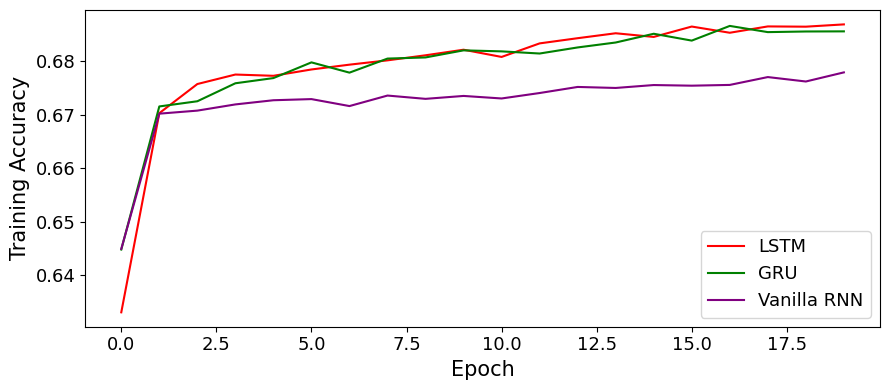

In [ ]:
# Training accuracy curves 

plt.figure(figsize=(9, 4))
plt.plot(history.history['accuracy'],  color='red',    label='LSTM')
plt.plot(history2.history['accuracy'], color='green',  label='GRU')
plt.plot(history3.history['accuracy'], color='purple', label='Vanilla RNN')
plt.xlabel('Epoch', size=15)
plt.ylabel('Training Accuracy', size=15)
plt.gca().tick_params(axis='x', labelsize=13)
plt.gca().tick_params(axis='y', labelsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('NVDA_Intrahour_Accuracy_Curves.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 24. Confusion Matrices

Side-by-side confusion matrices for all three models on the out-of-sample test set. This figure corresponds to **Figure 6.1** in the dissertation. Each cell reports the count of true negatives (Act 0, Pred 0), false positives (Act 0, Pred 1), false negatives (Act 1, Pred 0), and true positives (Act 1, Pred 1).

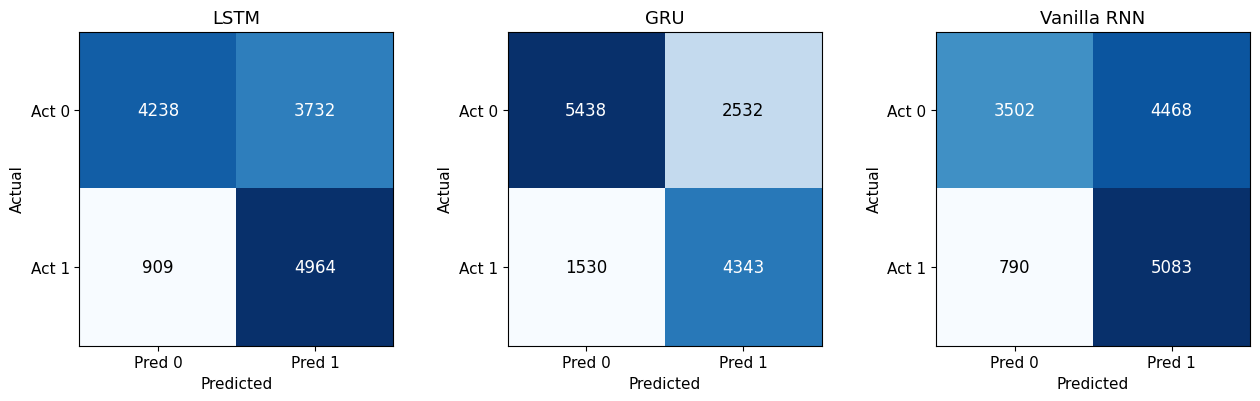

In [ ]:
# Confusion matrices

def plot_confusion_matrix(cm, title, ax):
    ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, size=13)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'], size=11)
    ax.set_yticklabels(['Act 0',  'Act 1'],  size=11)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center', size=12,
                color='white' if cm[i, j] > thresh else 'black')
    ax.set_ylabel('Actual', size=11)
    ax.set_xlabel('Predicted', size=11)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_confusion_matrix(cm_lstm, 'LSTM',        axes[0])
plot_confusion_matrix(cm_gru,  'GRU',         axes[1])
plot_confusion_matrix(cm_rnn,  'Vanilla RNN', axes[2])
plt.tight_layout()
plt.savefig('NVDA_Intrahour_Confusion_Matrices.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 25. Accuracy vs Training Time

A grouped bar chart comparing test accuracy and training time across the three architectures. This illustrates the efficiency trade-off between the models: the Vanilla RNN trains fastest but achieves the lowest accuracy, while the LSTM and GRU offer superior predictive performance at moderate additional computational cost.

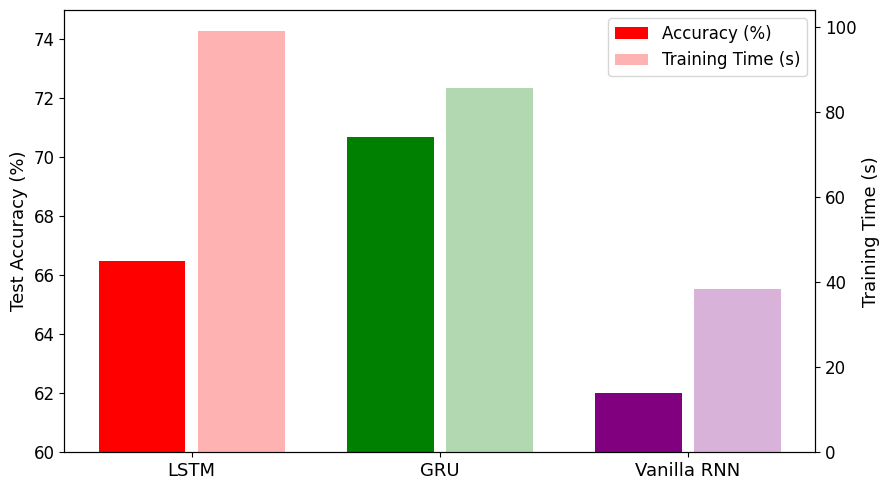

In [ ]:
# Accuracy vs training time bar chart

import matplotlib.pyplot as plt
import numpy as np

models     = ['LSTM', 'GRU', 'Vanilla RNN']
accuracies = [0.665, 0.707, 0.620]
aucs       = [0.772, 0.773, 0.739]
times      = [99.07, 85.77, 38.36]
colours    = ['red', 'green', 'purple']

# Accuracy vs Training Time
fig, ax1 = plt.subplots(figsize=(9, 5))
x = np.arange(len(models))

ax1.bar(x - 0.2, [a * 100 for a in accuracies], width=0.35, color=colours, label='Accuracy (%)')
ax1.set_ylabel('Test Accuracy (%)', size=13)
ax1.set_ylim(60, 75)
ax1.set_xticks(x)
ax1.set_xticklabels(models, size=13)
ax1.tick_params(axis='y', labelsize=12)

ax2 = ax1.twinx()
ax2.bar(x + 0.2, times, width=0.35, color=colours, alpha=0.3, label='Training Time (s)')
ax2.set_ylabel('Training Time (s)', size=13)
ax2.tick_params(axis='y', labelsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12)
plt.tight_layout()
plt.savefig('NVDA_Intrahour_Accuracy_vs_Time.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 26. Additional Imports

Imports for the ROC curve and grouped metrics bar chart produced in the sections below.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import roc_curve, auc

## 27. Grouped Metrics Bar Chart

All five classification metrics are plotted side-by-side for each model. This provides a consolidated visual summary of the trade-offs between accuracy, precision, sensitivity, specificity, and AUC across the three architectures.

The metric values here correspond to the out-of-sample results computed in Section 21 and reported in Table 6.1 of the dissertation.

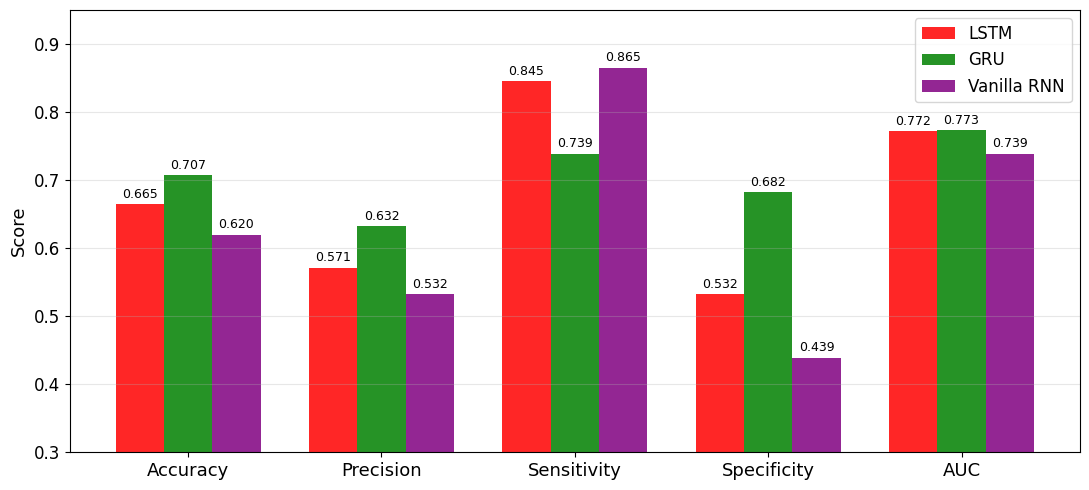

In [ ]:
# 3. Grouped Bar Chart — all five metrics 

metrics      = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'AUC']
lstm_vals    = [0.665, 0.571, 0.845, 0.532, 0.772]
gru_vals     = [0.707, 0.632, 0.739, 0.682, 0.773]
rnn_vals     = [0.620, 0.532, 0.865, 0.439, 0.739]

x      = np.arange(len(metrics))
width  = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width,     lstm_vals, width, color='red',    label='LSTM',        alpha=0.85)
bars2 = ax.bar(x,             gru_vals,  width, color='green',  label='GRU',         alpha=0.85)
bars3 = ax.bar(x + width,     rnn_vals,  width, color='purple', label='Vanilla RNN', alpha=0.85)

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, size=13)
ax.set_ylabel('Score', size=13)
ax.set_ylim(0.3, 0.95)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('NVDA_Intrahour_Metrics_Grouped_Bar.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()

## 28. Final Summary Table

The dissertation summary table is reproduced using the metric values for cross-reference with the narrative in Chapter 6.

In [ ]:
# 4. Dissertation Summary Table

print(f"{'Model':<15} | {'Accuracy':>8} | {'Precision':>9} | {'Sensitivity':>11} | {'Specificity':>11} | {'AUC':>6}")
print('-' * 75)
for name, vals in [('LSTM', lstm_vals), ('GRU', gru_vals), ('Vanilla RNN', rnn_vals)]:
    print(f"{name:<15} | {vals[0]:>8.3f} | {vals[1]:>9.3f} | {vals[2]:>11.3f} | {vals[3]:>11.3f} | {vals[4]:>6.3f}")

Model           | Accuracy | Precision | Sensitivity | Specificity |    AUC
---------------------------------------------------------------------------
LSTM            |    0.665 |     0.571 |       0.845 |       0.532 |  0.772
GRU             |    0.707 |     0.632 |       0.739 |       0.682 |  0.773
Vanilla RNN     |    0.620 |     0.532 |       0.865 |       0.439 |  0.739
